# Balufiks category model tested on Fashion-MNIST

This notebook uses **Fashion-MNIST** only as a test dataset, but the model structure is the same idea as the Balufiks category model:

- each class is treated as a product/category type
- the model predicts **which category** the image belongs to
- the notebook reports accuracy, loss, F1-score, ROC AUC, confusion matrix, TP, TN, FP, FN, PP and PN

Later, when you have the real Balufiks images, you should replace the Fashion-MNIST CSV loading section with an image-folder loader.


## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.cluster import KMeans

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Settings

The notebook first looks for an `archive` folder beside the notebook. If it cannot find it there, it also checks your Downloads folder.

Expected Fashion-MNIST structure:

```text
archive/
  fashion-mnist_train.csv
  fashion-mnist_test.csv
```


In [2]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (28, 28)
BATCH_SIZE = 64
EPOCHS = 10

possible_data_dirs = [
    Path("archive"),
    Path("/Users/dittegilsfeldt/Downloads/archive"),
    Path.home() / "Downloads" / "archive"
]

DATA_DIR = None
for path in possible_data_dirs:
    if (path / "fashion-mnist_train.csv").exists() and (path / "fashion-mnist_test.csv").exists():
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find fashion-mnist_train.csv and fashion-mnist_test.csv. "
        "Place the archive folder beside this notebook or update DATA_DIR manually."
    )

print("Using DATA_DIR:", DATA_DIR)

Using DATA_DIR: archive


## 3. Load Fashion-MNIST CSV files

This is the part that is specific to Fashion-MNIST. The real Balufiks model will later use image folders instead.


In [3]:
train_path = DATA_DIR / "fashion-mnist_train.csv"
test_path = DATA_DIR / "fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (60000, 785)
Test shape: (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Prepare images and labels

Fashion-MNIST has 784 pixel columns per image. We reshape them into `28 x 28 x 1` grayscale images.


In [4]:
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

num_classes = len(class_names)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Number of classes:", num_classes)

X_train: (60000, 28, 28, 1)
y_train: (60000,)
X_test: (10000, 28, 28, 1)
y_test: (10000,)
Number of classes: 10


## 5. Show example images

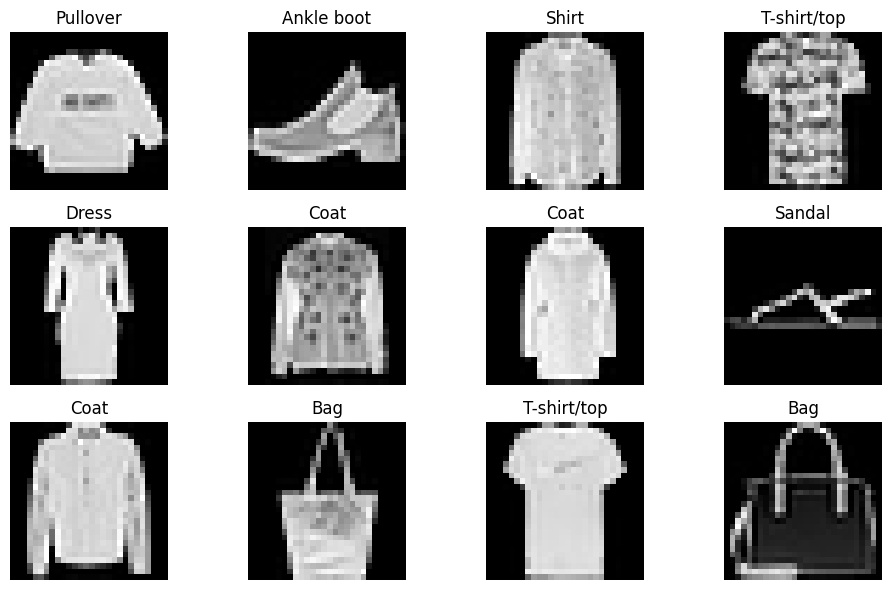

In [5]:
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Balufiks-style category model

This is a category classifier. For Balufiks, each output node would represent one Balufiks type. Here, each output node represents one Fashion-MNIST category.


In [6]:
def build_category_model(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu", name="feature_layer"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_category_model(input_shape=(28, 28, 1), num_classes=num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7920 - loss: 0.5729 - val_accuracy: 0.8661 - val_loss: 0.3856
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8628 - loss: 0.3799 - val_accuracy: 0.8817 - val_loss: 0.3237
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8806 - loss: 0.3282 - val_accuracy: 0.8892 - val_loss: 0.3005
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8911 - loss: 0.2962 - val_accuracy: 0.8963 - val_loss: 0.2897
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8990 - loss: 0.2720 - val_accuracy: 0.8860 - val_loss: 0.3023
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9075 - loss: 0.2505 - val_accuracy: 0.8983 - val_loss: 0.2795
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9135 - loss: 0.2334 - val_accuracy: 0.8944 - val_loss: 0.2901
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9183 - loss: 0.2180 - val_accuracy: 0

## 8. Plot accuracy and loss

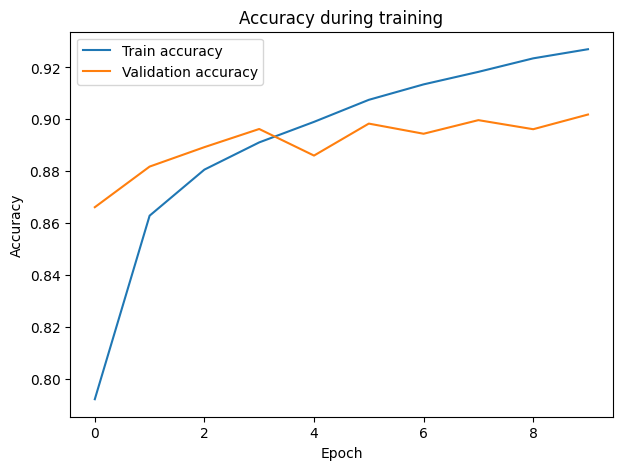

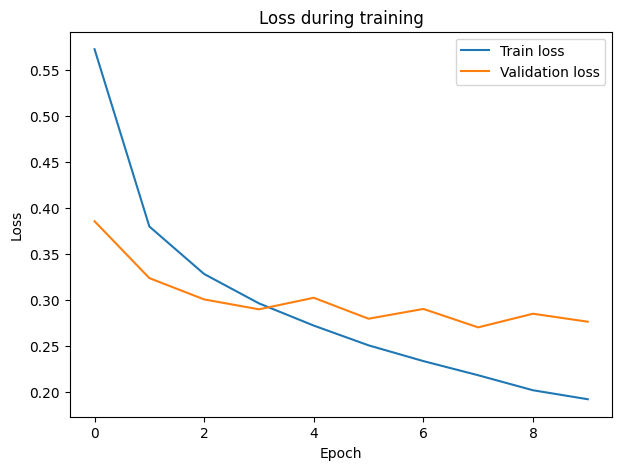

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.show()

## 9. Evaluate on test data

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))

Test loss: 0.2656
Test accuracy: 0.9038


## 10. Predictions

In [10]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 true labels:     ", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
First 10 true labels:      [0 1 2 2 3 2 8 6 5 0]
First 10 predicted labels: [0 1 2 6 3 6 8 6 5 0]


## 11. F1-score, precision and recall

In [11]:
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")

print("Macro F1-score:", round(macro_f1, 4))
print("Weighted F1-score:", round(weighted_f1, 4))
print("Macro precision:", round(macro_precision, 4))
print("Macro recall:", round(macro_recall, 4))

print("
Classification report:")
print(classification_report(y_test, y_pred, target_names=class_names))

SyntaxError: unterminated string literal (detected at line 11) (1124948716.py, line 11)

## 12. ROC AUC

ROC AUC is calculated as multiclass one-vs-rest because we have more than two categories.


In [ ]:
y_test_onehot = label_binarize(y_test, classes=list(range(num_classes)))

roc_auc_ovr = roc_auc_score(
    y_test_onehot,
    y_pred_prob,
    multi_class="ovr",
    average="macro"
)

print("ROC AUC OVR macro:", round(roc_auc_ovr, 4))

## 13. Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.colorbar()

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 14. TP, TN, FP, FN, PP and PN per category

For a multiclass model, these values are calculated one category at a time:

- TP: model predicted the category and it was correct
- TN: model did not predict the category and the true class was also another category
- FP: model predicted the category but the true class was another category
- FN: model did not predict the category but the true class was that category
- PP: predicted positive = TP + FP
- PN: predicted negative = TN + FN


In [ ]:
rows = []

for class_id, class_name in enumerate(class_names):
    y_true_binary = (y_test == class_id).astype(int)
    y_pred_binary = (y_pred == class_id).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

    rows.append({
        "class_id": class_id,
        "class_name": class_name,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "PP": tp + fp,
        "PN": tn + fn
    })

metrics_df = pd.DataFrame(rows)
metrics_df

## 15. Show misclassified images

In [ ]:
wrong_idx = np.where(y_test != y_pred)[0]
print("Number of wrong predictions:", len(wrong_idx))

plt.figure(figsize=(12, 8))
for i, idx in enumerate(wrong_idx[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"True: {class_names[y_test[idx]]}
Pred: {class_names[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 16. Elbow method on learned image features

This is not used to train the classifier. It is only used to inspect whether the model's learned features have cluster-like structure.


In [ ]:
feature_model = models.Model(
    inputs=model.input,
    outputs=model.get_layer("feature_layer").output
)

# Use a smaller subset to make KMeans faster
subset_size = min(3000, len(X_test))
X_features = feature_model.predict(X_test[:subset_size], verbose=0)

inertias = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_features)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow method on learned features")
plt.show()

## 17. Test one image

This function predicts one image and returns the most likely category.


In [ ]:
def predict_one_image(index):
    image = X_test[index:index+1]
    probabilities = model.predict(image, verbose=0)[0]
    predicted_class = np.argmax(probabilities)
    confidence = probabilities[predicted_class]

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title(
        f"Prediction: {class_names[predicted_class]} ({confidence:.2%})
"
        f"True: {class_names[y_test[index]]}"
    )
    plt.show()

    return {
        "predicted_class": class_names[predicted_class],
        "confidence": float(confidence),
        "true_class": class_names[y_test[index]]
    }

predict_one_image(0)

## 18. Save the model

In [ ]:
model_path = "balufiks_style_category_model_tested_on_fashion_mnist.keras"
model.save(model_path)
print("Model saved as:", model_path)

## 19. How to replace Fashion-MNIST with the real Balufiks dataset later

For the real Balufiks images, the folder structure should be:

```text
balufiks_dataset/
  category_1/
    image1.jpg
    image2.jpg
  category_2/
    image1.jpg
    image2.jpg
  category_3/
    image1.jpg
    image2.jpg
```

Then replace sections 3 and 4 with `tf.keras.utils.image_dataset_from_directory(...)` and change the model input shape to match the image size, for example `(224, 224, 3)`.
